# 08 - České výstupy pro aplikační část diplomové práce

Notebook pouze načítá uzamčené výsledky notebooků 06 a 07. Neprovádí výběr
modelů, přeučování ani Monte Carlo simulaci. Jeho účelem je:

- ověřit konzistenci výsledkových souborů;
- sjednotit české názvosloví;
- vytvořit přesně čtyři tabulky a čtyři obrázky určené pro část 3.2;
- exportovat obrázky jako vektorové PDF;
- exportovat tabulky jako CSV.

Brierovo skóre je v celém projektu počítáno jako průměr součtu čtvercových
odchylek přes všechny tři třídy H/D/A, tedy bez dodatečného dělení třemi.
Jeho rozsah je proto 0 až 2.


In [1]:
import ast
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CACHE_DIR = PROJECT_ROOT / ".cache" / "thesis_cs"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LEAGUE_ORDER = [
    "Bundesliga",
    "Premier League",
    "La Liga",
    "Ligue 1",
    "Serie A",
]
LEAGUE_CODES = {
    "BUNDESLIGA": "Bundesliga",
    "EPL": "Premier League",
    "LALIGA": "La Liga",
    "LIGUE_1": "Ligue 1",
    "SERIE_A": "Serie A",
}
OUTCOME_LABELS = {
    "H": "Výhra domácích",
    "D": "Remíza",
    "A": "Výhra hostů",
}
LEAGUE_COLOURS = {
    "Bundesliga": "#0072B2",
    "Premier League": "#E69F00",
    "La Liga": "#009E73",
    "Ligue 1": "#D55E00",
    "Serie A": "#CC79A7",
}
LEAGUE_MARKERS = {
    "Bundesliga": "o",
    "Premier League": "s",
    "La Liga": "^",
    "Ligue 1": "D",
    "Serie A": "P",
}
SNAPSHOT_LABELS = {
    0: "Před sezonou",
    1: "≈ 25 %",
    2: "≈ 50 %",
    3: "≈ 75 %",
}

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "grid.alpha": 0.22,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def czech_number(value, digits=2):
    return f"{value:.{digits}f}".replace(".", ",")


def save_figure(figure, filename):
    pdf_path = OUTPUT_DIR / f"{filename}.pdf"
    figure.savefig(pdf_path, bbox_inches="tight")
    print(f"Uloženo: {pdf_path.name}")
    return pdf_path


def write_csv_table(table, filename):
    path = OUTPUT_DIR / filename
    table.to_csv(path, index=False, encoding="utf-8")
    print(f"Uloženo: {path.name}")
    return path


## 1. Načtení a kontrola mezivýstupů

Všechny kontroly jsou záměrně provedeny před tvorbou prvního výstupu. Notebook
se zastaví, pokud chybí utkání, časový řez, pravděpodobnost nebo dohodnutá
metrika.


In [2]:
required_files = [
    "match_predictions_2024_25.parquet",
    "multiclass_by_scope.csv",
    "multiclass_overall.csv",
    "binary_overall.csv",
    "multiclass_benchmarks.csv",
    "prediction_horizon.csv",
    "model_registry.csv",
    "season_simulation_results.parquet",
    "season_position_probabilities.parquet",
    "season_evaluation.csv",
    "season_snapshot_plan.csv",
]
missing_files = [name for name in required_files if not (CACHE_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError(
        "Nejprve spusťte notebooky 06 a 07. Chybí: " + ", ".join(missing_files)
    )

match_predictions = pd.read_parquet(
    CACHE_DIR / "match_predictions_2024_25.parquet"
)
multiclass_by_scope = pd.read_csv(CACHE_DIR / "multiclass_by_scope.csv")
multiclass_overall = pd.read_csv(CACHE_DIR / "multiclass_overall.csv")
binary_overall = pd.read_csv(CACHE_DIR / "binary_overall.csv")
multiclass_benchmarks = pd.read_csv(
    CACHE_DIR / "multiclass_benchmarks.csv"
)
prediction_horizon = pd.read_csv(CACHE_DIR / "prediction_horizon.csv")
model_registry = pd.read_csv(CACHE_DIR / "model_registry.csv")
season_results = pd.read_parquet(
    CACHE_DIR / "season_simulation_results.parquet"
)
position_probabilities = pd.read_parquet(
    CACHE_DIR / "season_position_probabilities.parquet"
)
season_evaluation = pd.read_csv(CACHE_DIR / "season_evaluation.csv")
snapshot_plan = pd.read_csv(CACHE_DIR / "season_snapshot_plan.csv")

assert len(match_predictions) == 7_008
assert (
    match_predictions[["league_id", "game_id"]]
    .drop_duplicates()
    .shape[0]
    == 1_752
)
assert np.allclose(
    match_predictions[[
        "p_1x2_home",
        "p_1x2_draw",
        "p_1x2_away",
    ]].sum(axis=1),
    1.0,
)
assert len(season_results) == 384
assert len(season_evaluation) == 20
assert len(position_probabilities) == 7_392
assert np.allclose(
    position_probabilities.groupby(
        ["league_id", "snapshot_code", "team"]
    )["position_probability"].sum(),
    1.0,
)
assert season_evaluation["trps"].between(0, 1).all()
assert season_evaluation["rank_kendall"].between(-1, 1).all()
assert len(model_registry.loc[model_registry["target"].eq("1X2")]) == 12

market_league_results = multiclass_by_scope.loc[
    multiclass_by_scope["scope_type"].eq("league-specific")
    & multiclass_by_scope["branch"].eq("market")
]
best_market_league = market_league_results.loc[
    market_league_results["accuracy"].idxmax(),
    "scope",
]
assert best_market_league == "Ligue 1"

display(Markdown(
    f"Kontroly dokončeny: **1 752 utkání**, **20 sezonních časových řezů** "
    f"a **7 392 pravděpodobností umístění**. Nejvyšší přesnosti ligového "
    f"modelu s tržními informacemi dosáhla **{best_market_league}**."
))


Kontroly dokončeny: **1 752 utkání**, **20 sezonních časových řezů** a **7 392 pravděpodobností umístění**. Nejvyšší přesnosti ligového modelu s tržními informacemi dosáhla **Ligue 1**.

## 2. Tabulka dat a časového uspořádání

Vývojová data obsahují 5 404 utkání ze sezon 2021/2022 až 2023/2024.
Závěrečné testování probíhá na 1 752 utkáních sezony 2024/2025. Modely se
během závěrečného testu přeučují pouze z informací dostupných před
predikovaným časovým blokem.


In [3]:
feature_counts = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "match_features.csv",
    usecols=["season_id", "sample_role"],
)
counts_by_season = feature_counts.groupby("season_id").size().to_dict()
assert counts_by_season == {2021: 1826, 2022: 1826, 2023: 1752, 2024: 1752}

time_design = pd.DataFrame([
    {
        "Krok": "1. validační krok",
        "Trénovací období": "2021/2022",
        "Hodnocené období": "2022/2023",
        "Počet hodnocených utkání": 1826,
        "Váha": "40 %",
    },
    {
        "Krok": "2. validační krok",
        "Trénovací období": "2021/2022-2022/2023",
        "Hodnocené období": "2023/2024",
        "Počet hodnocených utkání": 1752,
        "Váha": "60 %",
    },
    {
        "Krok": "Závěrečné časové testování",
        "Trénovací období": "Rozšiřující se historie",
        "Hodnocené období": "2024/2025",
        "Počet hodnocených utkání": 1752,
        "Váha": "-",
    },
])
display(time_design)

table_data_path = write_csv_table(
    time_design,
    "tab_data_a_casove_rozdeleni.csv",
)


,Krok,Trénovací období,Hodnocené období,Počet hodnocených utkání,Váha
0,1. validační krok,2021/2022,2022/2023,1826,40 %
1,2. validační krok,2021/2022-2022/2023,2023/2024,1752,60 %
2,Závěrečné časové testování,Rozšiřující se historie,2024/2025,1752,-


Uloženo: tab_data_a_casove_rozdeleni.csv


## 3. Vybrané modely a výsledky predikce zápasů

Nejprve jsou shrnuty modely vybrané během časové validace. Číslo v závorce
udává počet vstupních proměnných výsledného modelu.

Hlavním hodnoticím kritériem je celková přesnost klasifikace. Brierovo skóre
doplňuje hodnocení pravděpodobnostního výstupu; nižší hodnota je lepší.
Logaritmická ztráta ani macro-F1 se do hlavní tabulky nepřenášejí.


In [4]:
MODEL_LABELS_CS = {
    "Multinomial logistic regression": "multinomická logistická regrese",
    "k-nearest neighbours": "metoda k nejbližších sousedů",
    "Calibrated linear support vector machine": "lineární SVM",
    "Random forest": "náhodný les",
    "CatBoost": "CatBoost",
}


def czech_model_description(row):
    if row["algorithm"] == "Equal-weight top-three ensemble":
        members = ast.literal_eval(row["hyperparameters"])
        labels = [MODEL_LABELS_CS[item["model_label"]] for item in members]
        model_name = "kombinovaný model: " + ", ".join(labels[:-1]) + " a " + labels[-1]
    else:
        model_name = MODEL_LABELS_CS[row["algorithm"]]
    return f"{model_name} ({int(row['features'])})"


selected_models = model_registry.loc[
    model_registry["target"].eq("1X2")
].copy()
selected_models["Oblast"] = selected_models["scope"].replace({
    "Pooled five-league model": "Společný model",
})
selected_models["Popis modelu"] = selected_models.apply(
    czech_model_description,
    axis=1,
)
model_table = (
    selected_models.pivot(
        index="Oblast",
        columns="branch",
        values="Popis modelu",
    )
    .reindex(LEAGUE_ORDER + ["Společný model"])
    .reset_index()
    .rename(columns={
        "structural": "Strukturální model",
        "market": "Model s tržními informacemi",
    })
)
model_table = model_table[[
    "Oblast",
    "Strukturální model",
    "Model s tržními informacemi",
]]
assert model_table.shape == (6, 3)
display(model_table)
table_models_path = write_csv_table(
    model_table,
    "tab_vybrane_modely_1x2.csv",
)


def benchmark_row(scope_code, branch, method):
    selected = multiclass_benchmarks.loc[
        multiclass_benchmarks["scope_code"].eq(scope_code)
        & multiclass_benchmarks["branch"].eq(branch)
        & multiclass_benchmarks["method"].eq(method)
    ]
    assert len(selected) == 1
    return selected.iloc[0]


match_table_records = []
for league_code, league_name in LEAGUE_CODES.items():
    structural = benchmark_row(
        league_code,
        "structural",
        "Locked direct 1X2 ML",
    )
    market_model = benchmark_row(
        league_code,
        "market",
        "Locked direct 1X2 ML",
    )
    direct_market = benchmark_row(
        league_code,
        "market",
        "Direct market probability",
    )
    poisson = benchmark_row(
        league_code,
        "structural",
        "Walk-forward Poisson",
    )
    frequency = benchmark_row(
        league_code,
        "structural",
        "Expanding training frequency",
    )
    market_with_interval = (
        f"{100 * market_model.accuracy:.2f} % "
        f"({100 * market_model.accuracy_ci_low:.2f}-"
        f"{100 * market_model.accuracy_ci_high:.2f})"
    )
    match_table_records.append({
        "Liga": league_name,
        "n": int(market_model.n_matches),
        "Strukturální model": structural.accuracy,
        "Model s tržními informacemi (95% IS)": market_with_interval,
        "Brierovo skóre": market_model.brier_score,
        "Přímý trh": direct_market.accuracy,
        "Poissonův model": poisson.accuracy,
        "Historické četnosti": frequency.accuracy,
    })

match_table = pd.DataFrame(match_table_records)
display(match_table.style.hide(axis="index").format({
    "Strukturální model": "{:.2%}",
    "Brierovo skóre": "{:.4f}",
    "Přímý trh": "{:.2%}",
    "Poissonův model": "{:.2%}",
    "Historické četnosti": "{:.2%}",
}))

match_table_export = match_table.copy()
for column in [
    "Strukturální model",
    "Přímý trh",
    "Poissonův model",
    "Historické četnosti",
]:
    match_table_export[column] = match_table_export[column].map(
        lambda value: f"{100 * value:.2f} %"
    )
match_table_export["Brierovo skóre"] = match_table_export[
    "Brierovo skóre"
].map(lambda value: f"{value:.4f}")

table_matches_path = write_csv_table(
    match_table_export,
    "tab_predikce_zapasu_1x2.csv",
)


branch,Oblast,Strukturální model,Model s tržními informacemi
0,Bundesliga,multinomická logistická regrese (14),kombinovaný model: metoda k nejbližších soused...
1,Premier League,"kombinovaný model: CatBoost, náhodný les a met...",CatBoost (18)
2,La Liga,metoda k nejbližších sousedů (14),metoda k nejbližších sousedů (18)
3,Ligue 1,"kombinovaný model: lineární SVM, multinomická ...",kombinovaný model: metoda k nejbližších soused...
4,Serie A,multinomická logistická regrese (18),lineární SVM (22)
5,Společný model,multinomická logistická regrese (15),kombinovaný model: multinomická logistická reg...


Uloženo: tab_vybrane_modely_1x2.csv


Liga,n,Strukturální model,Model s tržními informacemi (95% IS),Brierovo skóre,Přímý trh,Poissonův model,Historické četnosti
Bundesliga,306,50.65%,51.31 % (45.73-56.86),0.6031,52.79%,47.39%,38.56%
Premier League,380,53.16%,54.21 % (49.18-59.15),0.5789,55.53%,53.42%,40.79%
La Liga,380,53.16%,54.21 % (49.18-59.15),0.5702,55.53%,52.89%,44.47%
Ligue 1,306,54.58%,56.21 % (50.61-61.66),0.5748,55.23%,56.21%,46.73%
Serie A,380,52.63%,55.26 % (50.24-60.19),0.5853,54.09%,52.11%,39.74%


Uloženo: tab_predikce_zapasu_1x2.csv


## 4. Vývoj přesnosti v průběhu sezóny

Kumulativní přesnost vyjadřuje podíl správně klasifikovaných výsledků od
začátku testovací sezóny do daného časového okamžiku. Jednotlivé body
odpovídají koncům bloků přeučení. Kvůli nestabilitě prvních pozorování je
vývoj zobrazen až po alespoň 18 odehraných utkáních.


Uloženo: obr_vyvoj_kumulativni_presnosti_1x2.pdf


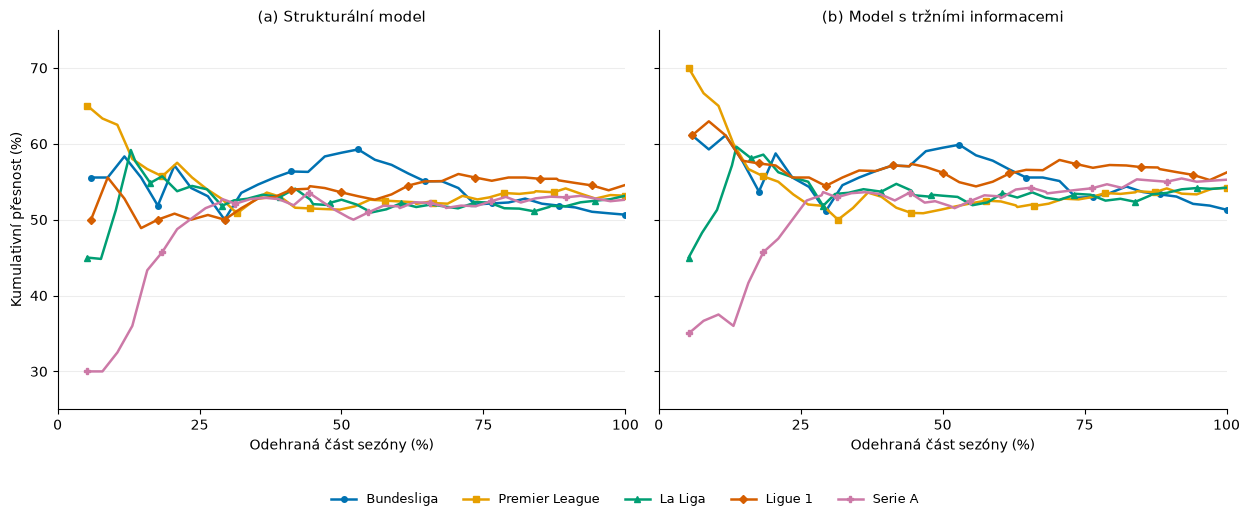

In [5]:
trajectory_1x2 = (
    match_predictions.loc[
        match_predictions["scope_type"].eq("league-specific")
    ]
    .sort_values(["scope_code", "branch", "date", "game_id"])
    .copy()
)

result_labels = np.array(["H", "D", "A"])
probability_columns = [
    "p_1x2_home",
    "p_1x2_draw",
    "p_1x2_away",
]
trajectory_1x2["predicted_1x2"] = result_labels[
    np.argmax(
        trajectory_1x2[probability_columns].to_numpy(),
        axis=1,
    )
]
trajectory_1x2["correct_1x2"] = (
    trajectory_1x2["predicted_1x2"]
    == trajectory_1x2["observed_1x2"]
).astype(int)

trajectory_groups = trajectory_1x2.groupby(
    ["scope_code", "branch"],
    sort=False,
)
trajectory_1x2["cumulative_accuracy"] = trajectory_groups[
    "correct_1x2"
].transform(lambda values: values.expanding().mean())
trajectory_1x2["cumulative_matches"] = (
    trajectory_groups.cumcount() + 1
)
trajectory_1x2["total_matches"] = trajectory_groups[
    "game_id"
].transform("size")
trajectory_1x2["completed_share"] = (
    trajectory_1x2["cumulative_matches"]
    / trajectory_1x2["total_matches"]
)

block_end_trajectory = (
    trajectory_1x2.groupby(
        ["scope_code", "scope", "branch", "walk_block"],
        as_index=False,
        sort=True,
    )
    .agg(
        cumulative_accuracy=("cumulative_accuracy", "last"),
        cumulative_matches=("cumulative_matches", "last"),
        completed_share=("completed_share", "last"),
    )
    .sort_values(["scope_code", "branch", "walk_block"])
)
block_end_trajectory = block_end_trajectory.loc[
    block_end_trajectory["cumulative_matches"].ge(18)
].copy()

for league_code, league_name in LEAGUE_CODES.items():
    for branch in ["structural", "market"]:
        plotted_rows = block_end_trajectory.loc[
            block_end_trajectory["scope_code"].eq(league_code)
            & block_end_trajectory["branch"].eq(branch)
        ].sort_values("walk_block")
        recorded_accuracy = multiclass_by_scope.loc[
            multiclass_by_scope["scope_code"].eq(league_code)
            & multiclass_by_scope["scope_type"].eq("league-specific")
            & multiclass_by_scope["branch"].eq(branch),
            "accuracy",
        ].iloc[0]
        assert np.isclose(
            plotted_rows["cumulative_accuracy"].iloc[-1],
            recorded_accuracy,
        )

branch_titles = {
    "structural": "(a) Strukturální model",
    "market": "(b) Model s tržními informacemi",
}
league_name_to_code = {
    league_name: league_code
    for league_code, league_name in LEAGUE_CODES.items()
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.6, 5.2),
    sharex=True,
    sharey=True,
)
for axis, branch in zip(axes, ["structural", "market"]):
    for league_name in LEAGUE_ORDER:
        league_code = league_name_to_code[league_name]
        rows = block_end_trajectory.loc[
            block_end_trajectory["scope_code"].eq(league_code)
            & block_end_trajectory["branch"].eq(branch)
        ].sort_values("walk_block")
        axis.plot(
            100 * rows["completed_share"],
            100 * rows["cumulative_accuracy"],
            color=LEAGUE_COLOURS[league_name],
            marker=LEAGUE_MARKERS[league_name],
            markevery=max(1, len(rows) // 8),
            markersize=4,
            linewidth=1.8,
            label=league_name,
        )
    axis.set_title(branch_titles[branch])
    axis.set_xlabel("Odehraná část sezóny (%)")
    axis.set_xlim(0, 100)
    axis.set_ylim(25, 75)
    axis.set_xticks([0, 25, 50, 75, 100])
    axis.grid(axis="y", alpha=0.22)

axes[0].set_ylabel("Kumulativní přesnost (%)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.005),
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.09, 1, 1])
match_accuracy_evolution_paths = save_figure(
    fig,
    "obr_vyvoj_kumulativni_presnosti_1x2",
)
plt.show()


## 5. Detail zápasových predikcí Ligue 1

Ligue 1 je zvolena pro podrobnější prezentaci, protože model s tržními
informacemi v této lize dosáhl z pěti sledovaných soutěží nejvyšší celkové
přesnosti. Matice záměn současně ukazuje chování vůči remízám a kalibrační
křivky porovnávají predikované pravděpodobnosti s pozorovanými četnostmi.


Uloženo: obr_ligue1_matice_zamen_kalibrace.pdf


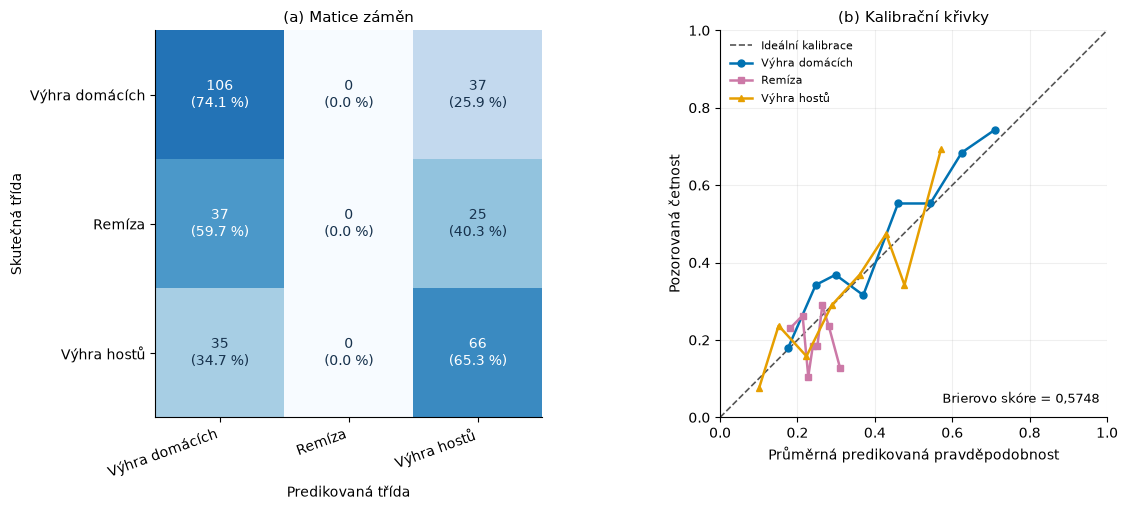

In [6]:
ligue1_matches = match_predictions.loc[
    match_predictions["scope_code"].eq("LIGUE_1")
    & match_predictions["branch"].eq("market")
].sort_values(["date", "game_id"])
assert len(ligue1_matches) == 306

class_order = np.array(["H", "D", "A"])
probabilities = ligue1_matches[[
    "p_1x2_home",
    "p_1x2_draw",
    "p_1x2_away",
]].to_numpy()
predicted = class_order[np.argmax(probabilities, axis=1)]
observed = ligue1_matches["observed_1x2"].to_numpy()
matrix = confusion_matrix(observed, predicted, labels=class_order)
matrix_share = matrix / matrix.sum(axis=1, keepdims=True)
observed_matrix = (observed[:, None] == class_order[None, :]).astype(float)
ligue1_brier = np.mean(np.sum((probabilities - observed_matrix) ** 2, axis=1))

recorded_ligue1_brier = market_league_results.loc[
    market_league_results["scope"].eq("Ligue 1"),
    "brier_score",
].iloc[0]
assert np.isclose(ligue1_brier, recorded_ligue1_brier)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.2))

image = axes[0].imshow(matrix_share, cmap="Blues", vmin=0, vmax=1)
for row in range(3):
    for column in range(3):
        share = matrix_share[row, column]
        axes[0].text(
            column,
            row,
            f"{matrix[row, column]}\n({100 * share:.1f} %)",
            ha="center",
            va="center",
            fontsize=10,
            color="white" if share > 0.48 else "#17324D",
        )
class_names = [OUTCOME_LABELS[label] for label in class_order]
axes[0].set_xticks(range(3), class_names, rotation=20, ha="right")
axes[0].set_yticks(range(3), class_names)
axes[0].set_xlabel("Predikovaná třída")
axes[0].set_ylabel("Skutečná třída")
axes[0].set_title("(a) Matice záměn")

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    color="#555555",
    label="Ideální kalibrace",
)
calibration_styles = [
    ("H", "p_1x2_home", "#0072B2", "o"),
    ("D", "p_1x2_draw", "#CC79A7", "s"),
    ("A", "p_1x2_away", "#E69F00", "^"),
]
for label, probability_column, colour, marker in calibration_styles:
    observed_binary = ligue1_matches["observed_1x2"].eq(label).astype(int)
    observed_rate, predicted_mean = calibration_curve(
        observed_binary,
        ligue1_matches[probability_column],
        n_bins=8,
        strategy="quantile",
    )
    axes[1].plot(
        predicted_mean,
        observed_rate,
        marker=marker,
        linewidth=1.8,
        markersize=5,
        color=colour,
        label=OUTCOME_LABELS[label],
    )
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("Průměrná predikovaná pravděpodobnost")
axes[1].set_ylabel("Pozorovaná četnost")
axes[1].set_title("(b) Kalibrační křivky")
axes[1].grid(alpha=0.20)
axes[1].legend(loc="upper left", fontsize=8)
axes[1].text(
    0.98,
    0.03,
    f"Brierovo skóre = {czech_number(ligue1_brier, 4)}",
    transform=axes[1].transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
)

fig.tight_layout()
match_detail_paths = save_figure(
    fig,
    "obr_ligue1_matice_zamen_kalibrace",
)
plt.show()


## 6. Vývoj kvality sezonních predikcí

Čtyři panely odpovídají metrikám používaným v teoretické části práce:
RMSE bodového zisku, MSE pořadí, Kendallovu tau a TRPS. Jednotlivé body
představují skutečný nejbližší dokončený časový blok, nikoli mechanický řez
uprostřed rozehraného kola.


Uloženo: obr_vyvoj_sezonnich_metrik.pdf


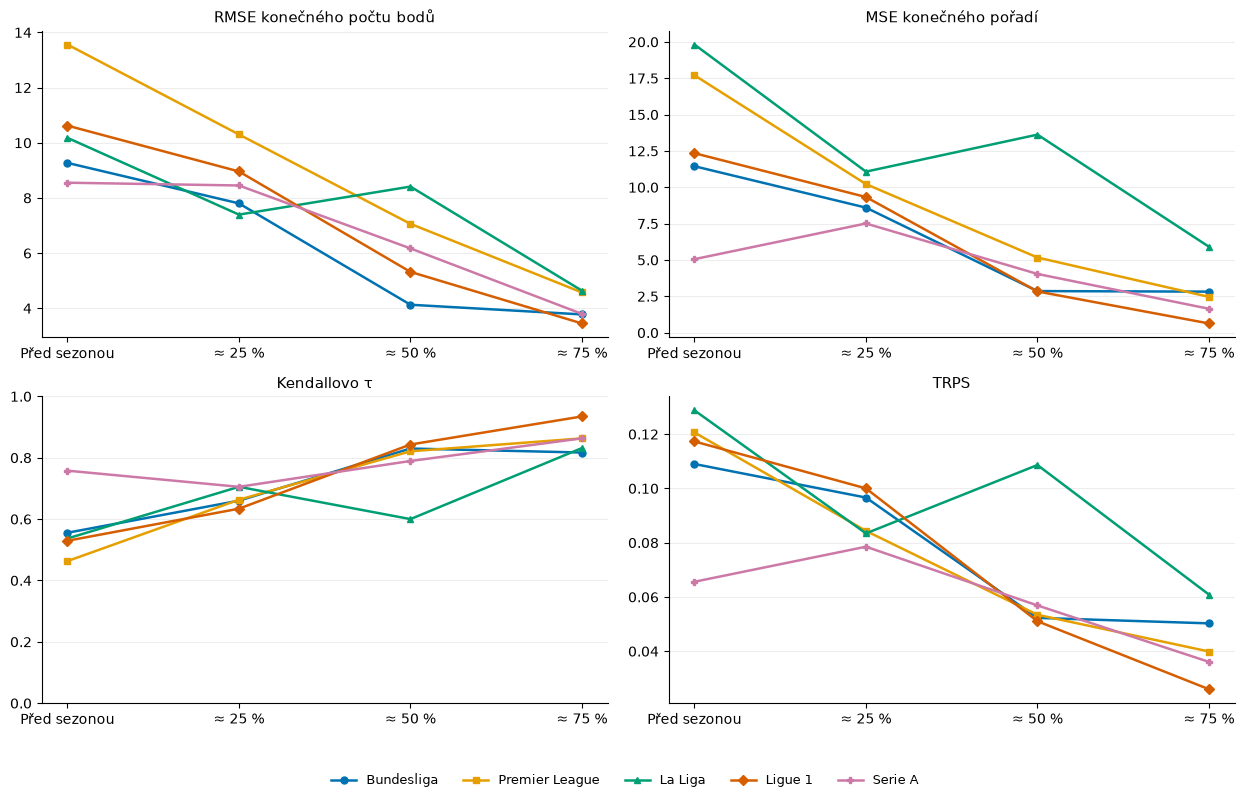

In [7]:
metric_panels = [
    ("points_rmse", "RMSE konečného počtu bodů", False),
    ("position_mse", "MSE konečného pořadí", False),
    ("rank_kendall", "Kendallovo τ", True),
    ("trps", "TRPS", False),
]

fig, axes = plt.subplots(2, 2, figsize=(12.6, 8.0))
for axis, (metric, title, higher_better) in zip(
    axes.ravel(),
    metric_panels,
):
    for league_name in LEAGUE_ORDER:
        rows = season_evaluation.loc[
            season_evaluation["league"].eq(league_name)
        ].sort_values("snapshot_order")
        axis.plot(
            rows["snapshot_order"],
            rows[metric],
            color=LEAGUE_COLOURS[league_name],
            marker=LEAGUE_MARKERS[league_name],
            markersize=5,
            linewidth=1.8,
            label=league_name,
        )
    axis.set_title(title)
    axis.set_xticks(
        range(4),
        [SNAPSHOT_LABELS[index] for index in range(4)],
    )
    axis.grid(axis="y", alpha=0.22)
    if higher_better:
        axis.set_ylim(0, 1)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.005),
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.065, 1, 1])
season_evolution_paths = save_figure(
    fig,
    "obr_vyvoj_sezonnich_metrik",
)
plt.show()


## 7. Souhrn sezonních výsledků

Pro každou ligu je uvedena predikce před sezonou a poslední dostupný řez
přibližně po třech čtvrtinách utkání. Mistr, evropské pozice a přímý sestup
jsou vyjádřeny počtem správně identifikovaných týmů ku počtu příslušných míst.


In [8]:
selected_season_rows = season_evaluation.loc[
    season_evaluation["snapshot_order"].isin([0, 3])
].copy()
selected_season_rows["league_order"] = pd.Categorical(
    selected_season_rows["league"],
    categories=LEAGUE_ORDER,
    ordered=True,
)
selected_season_rows = selected_season_rows.sort_values(
    ["league_order", "snapshot_order"]
)

season_table_records = []
for row in selected_season_rows.itertuples(index=False):
    time_label = (
        "Před sezonou"
        if row.snapshot_order == 0
        else "Přibližně 75 %"
    )
    champion_value = f"{int(row.predicted_champion_correct)}/1"
    europe_value = f"{int(row.correct_european_teams)}/{int(row.european_places)}"
    relegation_value = (
        f"{int(row.correct_direct_relegation_teams)}/"
        f"{int(row.direct_relegation_places)}"
    )
    season_table_records.append({
        "Liga": row.league,
        "Časový řez": time_label,
        "Odehráno": row.completed_fraction,
        "RMSE bodů": row.points_rmse,
        "MSE pořadí": row.position_mse,
        "Kendallovo τ": row.rank_kendall,
        "TRPS": row.trps,
        "Mistr": champion_value,
        "Evropa": europe_value,
        "Přímý sestup": relegation_value,
    })

season_table = pd.DataFrame(season_table_records)
display(season_table.style.hide(axis="index").format({
    "Odehráno": "{:.1%}",
    "RMSE bodů": "{:.2f}",
    "MSE pořadí": "{:.2f}",
    "Kendallovo τ": "{:.3f}",
    "TRPS": "{:.4f}",
}))

season_table_export = season_table.copy()
season_table_export["Odehráno"] = season_table_export["Odehráno"].map(
    lambda value: f"{100 * value:.1f} %"
)
for column in ["RMSE bodů", "MSE pořadí"]:
    season_table_export[column] = season_table_export[column].map(
        lambda value: f"{value:.2f}"
    )
season_table_export["Kendallovo τ"] = season_table_export[
    "Kendallovo τ"
].map(lambda value: f"{value:.3f}")
season_table_export["TRPS"] = season_table_export["TRPS"].map(
    lambda value: f"{value:.4f}"
)

table_seasons_path = write_csv_table(
    season_table_export,
    "tab_predikce_sezon.csv",
)


Liga,Časový řez,Odehráno,RMSE bodů,MSE pořadí,Kendallovo τ,TRPS,Mistr,Evropa,Přímý sestup
Bundesliga,Před sezonou,0.0%,9.27,11.45,0.556,0.1090,1/1,4/6,1/2
Bundesliga,Přibližně 75 %,73.5%,3.78,2.82,0.817,0.0503,1/1,5/6,1/2
Premier League,Před sezonou,0.0%,13.56,17.71,0.463,0.1206,0/1,6/7,1/3
Premier League,Přibližně 75 %,73.9%,4.57,2.46,0.863,0.0399,1/1,6/7,3/3
La Liga,Před sezonou,0.0%,10.18,19.82,0.537,0.1288,0/1,6/8,2/3
La Liga,Přibližně 75 %,76.1%,4.64,5.91,0.832,0.0609,1/1,8/8,2/3
Ligue 1,Před sezonou,0.0%,10.62,12.35,0.529,0.1173,1/1,5/7,1/2
Ligue 1,Přibližně 75 %,73.5%,3.45,0.64,0.935,0.0260,1/1,7/7,2/2
Serie A,Před sezonou,0.0%,8.55,5.06,0.758,0.0656,0/1,4/6,1/3
Serie A,Přibližně 75 %,73.7%,3.80,1.65,0.863,0.0361,0/1,4/6,3/3


Uloženo: tab_predikce_sezon.csv


## 8. Detail sezonní predikce Ligue 1

Body představují očekávané konečné pořadí, vodorovné úsečky interval mezi
10. a 90. percentilem simulací a křížky skutečné konečné pořadí. Stejné pořadí
klubů v obou panelech umožňuje přímo sledovat zpřesnění predikce.


Uloženo: obr_ligue1_intervaly_poradi.pdf


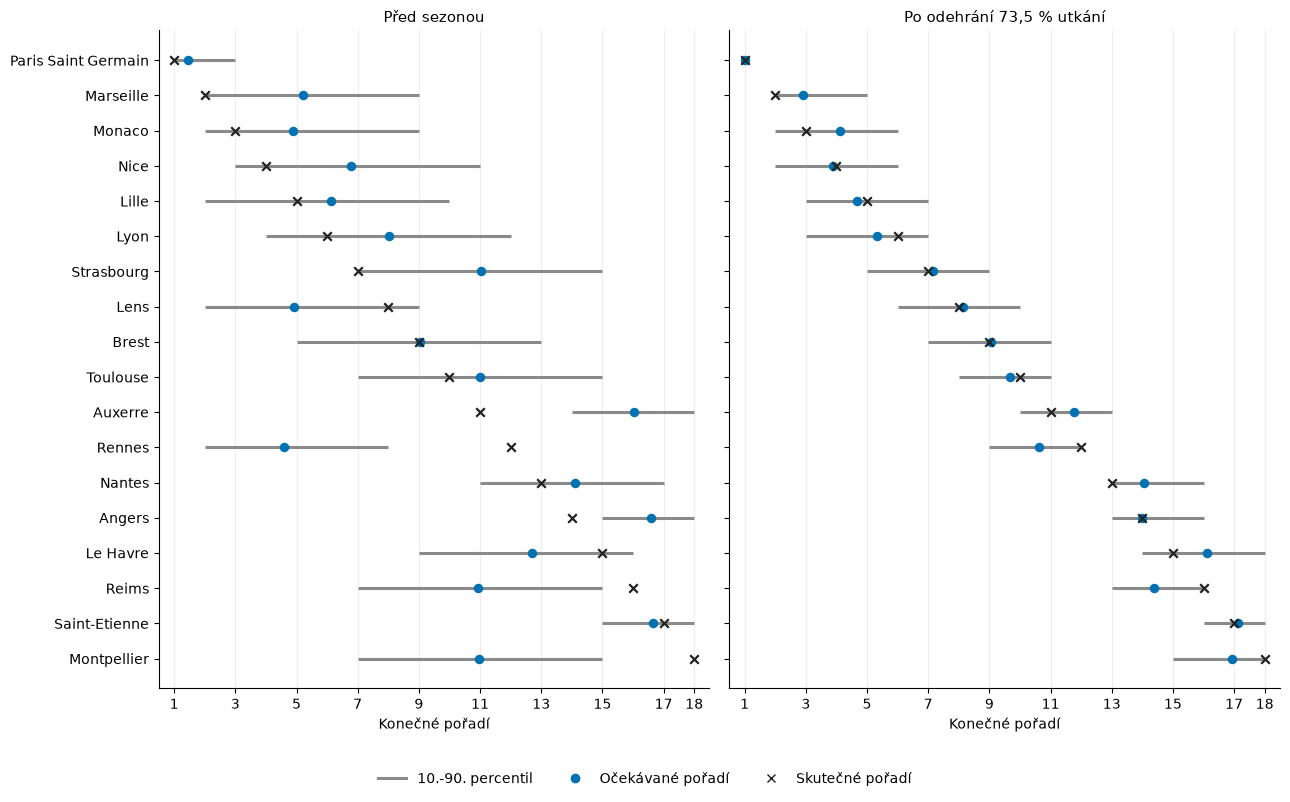

In [9]:
ligue1_season = season_results.loc[
    season_results["league_id"].eq("LIGUE_1")
    & season_results["snapshot_order"].isin([0, 3])
].copy()
assert len(ligue1_season) == 36

team_order = (
    ligue1_season.loc[ligue1_season["snapshot_order"].eq(0)]
    .sort_values("actual_position")["team"]
    .tolist()
)
y_positions = np.arange(len(team_order))
late_fraction = ligue1_season.loc[
    ligue1_season["snapshot_order"].eq(3),
    "completed_fraction",
].iloc[0]
panel_titles = {
    0: "Před sezonou",
    3: f"Po odehrání {czech_number(100 * late_fraction, 1)} % utkání",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.0, 8.0),
    sharey=True,
)
for axis, snapshot_order in zip(axes, [0, 3]):
    rows = (
        ligue1_season.loc[
            ligue1_season["snapshot_order"].eq(snapshot_order)
        ]
        .set_index("team")
        .loc[team_order]
    )
    axis.hlines(
        y_positions,
        rows["position_p10"],
        rows["position_p90"],
        color="#8A8A8A",
        linewidth=2.2,
        label="10.-90. percentil",
    )
    axis.scatter(
        rows["expected_position"],
        y_positions,
        color="#0072B2",
        s=34,
        marker="o",
        zorder=3,
        label="Očekávané pořadí",
    )
    axis.scatter(
        rows["actual_position"],
        y_positions,
        color="#222222",
        s=38,
        marker="x",
        linewidth=1.6,
        zorder=4,
        label="Skutečné pořadí",
    )
    axis.set_xlim(0.5, 18.5)
    axis.set_xticks([1, 3, 5, 7, 9, 11, 13, 15, 17, 18])
    axis.set_xlabel("Konečné pořadí")
    axis.set_title(panel_titles[snapshot_order])
    axis.grid(axis="x", alpha=0.22)

axes[0].set_yticks(y_positions, team_order)
axes[0].invert_yaxis()
legend_handles = [
    Line2D([0], [0], color="#8A8A8A", linewidth=2.2, label="10.-90. percentil"),
    Line2D(
        [0],
        [0],
        color="#0072B2",
        marker="o",
        linestyle="none",
        label="Očekávané pořadí",
    ),
    Line2D(
        [0],
        [0],
        color="#222222",
        marker="x",
        linestyle="none",
        label="Skutečné pořadí",
    ),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.005),
)
fig.tight_layout(rect=[0, 0.06, 1, 1])
ligue1_season_paths = save_figure(
    fig,
    "obr_ligue1_intervaly_poradi",
)
plt.show()


## 9. Kontrola vytvořených souborů

Výstupní adresář obsahuje čtyři tabulky ve formátu CSV a čtyři obrázky ve
formátu PDF.


In [10]:
expected_outputs = [
    "tab_data_a_casove_rozdeleni.csv",
    "tab_vybrane_modely_1x2.csv",
    "tab_predikce_zapasu_1x2.csv",
    "tab_predikce_sezon.csv",
    "obr_vyvoj_kumulativni_presnosti_1x2.pdf",
    "obr_ligue1_matice_zamen_kalibrace.pdf",
    "obr_vyvoj_sezonnich_metrik.pdf",
    "obr_ligue1_intervaly_poradi.pdf",
]
missing_outputs = [
    name for name in expected_outputs if not (OUTPUT_DIR / name).exists()
]
assert not missing_outputs, missing_outputs
unexpected_outputs = sorted(
    path.name
    for path in OUTPUT_DIR.iterdir()
    if path.is_file()
    and path.name != "README.md"
    and path.name not in expected_outputs
)
assert not unexpected_outputs, unexpected_outputs

output_inventory = pd.DataFrame([
    {
        "Soubor": name,
        "Velikost (kB)": (OUTPUT_DIR / name).stat().st_size / 1024,
    }
    for name in expected_outputs
])
display(output_inventory.style.hide(axis="index").format({
    "Velikost (kB)": "{:.1f}",
}))
display(Markdown(f"Výstupy jsou uloženy v `{OUTPUT_DIR}`."))


Soubor,Velikost (kB)
tab_data_a_casove_rozdeleni.csv,0.3
tab_vybrane_modely_1x2.csv,0.8
tab_predikce_zapasu_1x2.csv,0.5
tab_predikce_sezon.csv,0.8
obr_vyvoj_kumulativni_presnosti_1x2.pdf,21.8
obr_ligue1_matice_zamen_kalibrace.pdf,18.0
obr_vyvoj_sezonnich_metrik.pdf,21.3
obr_ligue1_intervaly_poradi.pdf,17.5


Výstupy jsou uloženy v `C:\Users\cerve\Desktop\DP\match_prediction\outputs`.